# Extension 2: CP-Decomposition Analysis

This notebook analyzes CP (Canonical Polyadic) decomposition as an **architectural constraint** for intrinsic interpretability.

## Research Question
Does forcing low-rank structure via CP decomposition improve interpretability compared to emergent low-rank behavior (from regularization)?

## Methodology

CP parameterizes the interaction tensor as a sum of rank-1 tensors:
$$W_{cij} = \sum_{r=1}^{R} \lambda_r A_{cr} B_{ir} C_{jr}$$

Unlike eigendecomposition, CP does NOT enforce orthogonality—enabling disentangled representations.

### Three Variants
1. **Fixed CP**: Hard rank constraint, no additional regularization
2. **Lambda CP**: L1 regularization on learnable scales λᵣ for soft sparsity
3. **Gated CP**: Stochastic gates with L0 proxy for explicit rank pruning

All variants trained on MNIST with weight decay 0.1 across rank sweep R ∈ {32, 64, 128, 256}.

## 1. Setup


In [1]:
import sys
from pathlib import Path

# Add project root to path (works from notebooks/ or project root)
cwd = Path.cwd()
if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

sys.path.insert(0, str(PROJECT_ROOT))

# Download artifacts if not present
from src.artifact_loader import ensure_checkpoints
ensure_checkpoints()

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Centralized paths
from src.paths import (
    EXTENSION_CP_CHECKPOINTS as CP_CHECKPOINT_DIR,
    MNIST_CHECKPOINTS as DENSE_CHECKPOINT_DIR,
    MNIST_CHECKPOINTS as P1_CHECKPOINT_DIR,  # Alias for Phase 1 compatibility
    EXTENSION_CP_FIGURES as FIGURE_DIR,
    ensure_dir,
)

from src.vision.spectral import (
    load_checkpoint_eigenvalues,
    effective_rank,
    spectral_summary,
    top_k_coverage,
)

# Ensure directories exist
ensure_dir(FIGURE_DIR)

print(f"CP Checkpoints: {CP_CHECKPOINT_DIR}")
print(f"Dense/Phase1 Checkpoints: {P1_CHECKPOINT_DIR}")
print(f"Figures: {FIGURE_DIR}")


Checkpoints directory already exists: /Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025/checkpoints


CP Checkpoints: /Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025/checkpoints/extension_cp
Dense/Phase1 Checkpoints: /Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025/checkpoints/vision/mnist
Figures: /Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025/Report/figures/extension_cp


## 2. Load All CP Checkpoints


In [2]:
ranks = [16, 32, 64, 128, 256]
modes = ['fixed', 'lambda', 'gated']
seeds = [42, 43, 44, 45, 46]

cp_results = []
for rank in ranks:
    for mode in modes:
        for seed in seeds:
            # Pattern: mnist_cp_r{rank}_{mode}_seed{seed}.pt
            path = CP_CHECKPOINT_DIR / f"mnist_cp_r{rank}_{mode}_seed{seed}.pt"
            if not path.exists():
                continue
            
            checkpoint = torch.load(path, map_location='cpu', weights_only=False)
            eigenvalues = checkpoint['eigenvalues']
            metrics = checkpoint['metrics']
            
            # Compute additional metrics
            summary = spectral_summary(eigenvalues)
            
            cp_results.append({
                'cp_mode': mode,
                'rank': rank,
                'seed': seed,
                'accuracy': metrics['val_acc'],
                'effective_rank': metrics['effective_rank'],
                'top5_coverage': summary['top5_coverage_mean'],
                'top10_coverage': summary['top10_coverage_mean'],
            })

cp_df = pd.DataFrame(cp_results)
print(f"Loaded {len(cp_df)} CP checkpoints")
if len(cp_df) > 0:
    print(f"  Ranks: {sorted(cp_df['rank'].unique())}")
    print(f"  Modes: {sorted(cp_df['cp_mode'].unique())}")
    cp_df.head()

Loaded 75 CP checkpoints
  Ranks: [np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256)]
  Modes: ['fixed', 'gated', 'lambda']


## 3. Load Phase 1 Baselines for Comparison


In [3]:
p1_results = []
for config in ['none', 'full']:
    for seed in seeds:
        path = P1_CHECKPOINT_DIR / f"mnist_dense_{config}_seed{seed}.pt"
        if not path.exists():
            print(f"Warning: {path} not found")
            continue
        
        checkpoint = torch.load(path, map_location='cpu', weights_only=False)
        eigenvalues = checkpoint['eigenvalues']
        metrics = checkpoint['metrics']
        
        # Compute additional metrics
        summary = spectral_summary(eigenvalues)
        
        p1_results.append({
            'mode': f'dense_{config}',
            'rank': None,
            'seed': seed,
            'accuracy': metrics['val_acc'],
            'effective_rank': metrics['effective_rank'],
            'top5_coverage': summary['top5_coverage_mean'],
            'top10_coverage': summary['top10_coverage_mean'],
        })

p1_df = pd.DataFrame(p1_results)
print(f"Loaded {len(p1_df)} Phase 1 checkpoints")
if len(p1_df) > 0:
    p1_df.head()
else:
    print("(Phase 1 baselines not found - analysis will continue with CP models only)")


Loaded 10 Phase 1 checkpoints


## 4. Accuracy vs CP Rank


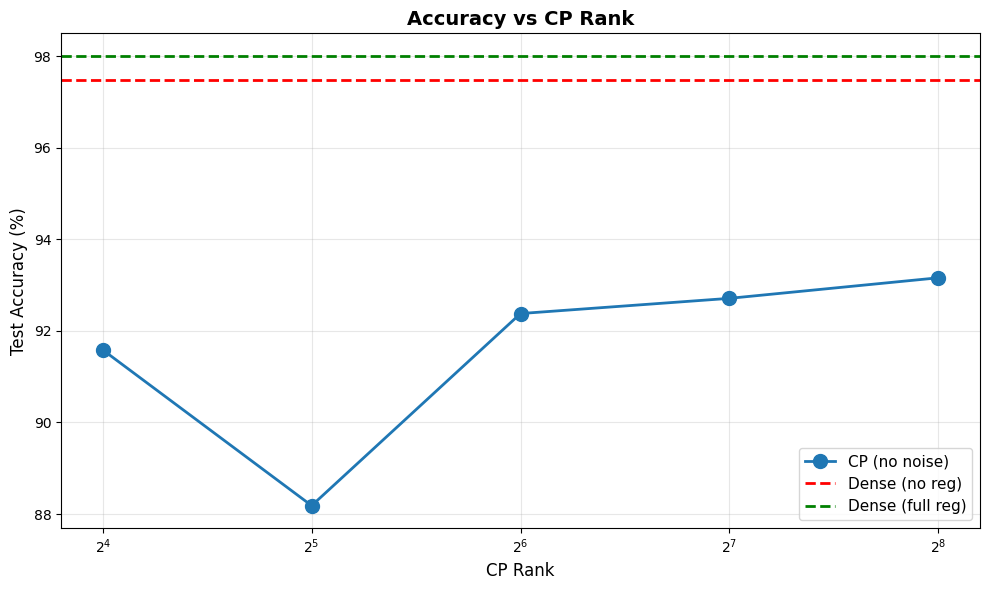

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

if len(cp_df) > 0:
    # Aggregate CP results by rank (single seed, so no std needed)
    cp_agg = cp_df.groupby('rank').agg({
        'accuracy': 'mean',
        'effective_rank': 'mean'
    }).reset_index()
    cp_agg.columns = ['rank', 'acc_mean', 'eff_mean']
    
    # Plot without error bars (single seed)
    ax.plot(cp_agg['rank'], cp_agg['acc_mean'] * 100, 'o-', 
            label='CP (no noise)', markersize=10, linewidth=2)
else:
    print("No CP checkpoints loaded - cannot create plot")
    plt.close(fig)

# Add dense baselines as horizontal lines (if available)
if len(p1_df) > 0:
    dense_none_subset = p1_df[p1_df['mode'] == 'dense_none']
    dense_full_subset = p1_df[p1_df['mode'] == 'dense_full']
    
    if len(dense_none_subset) > 0:
        dense_none_acc = dense_none_subset['accuracy'].mean() * 100
        ax.axhline(dense_none_acc, color='red', linestyle='--', linewidth=2, label='Dense (no reg)')
    
    if len(dense_full_subset) > 0:
        dense_full_acc = dense_full_subset['accuracy'].mean() * 100
        ax.axhline(dense_full_acc, color='green', linestyle='--', linewidth=2, label='Dense (full reg)')

if len(cp_df) > 0:
    ax.set_xlabel('CP Rank', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('Accuracy vs CP Rank', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_xscale('log', base=2)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "cp_accuracy_vs_rank.pdf", dpi=300, bbox_inches='tight')
    plt.show()


## 5. Effective Rank vs CP Rank


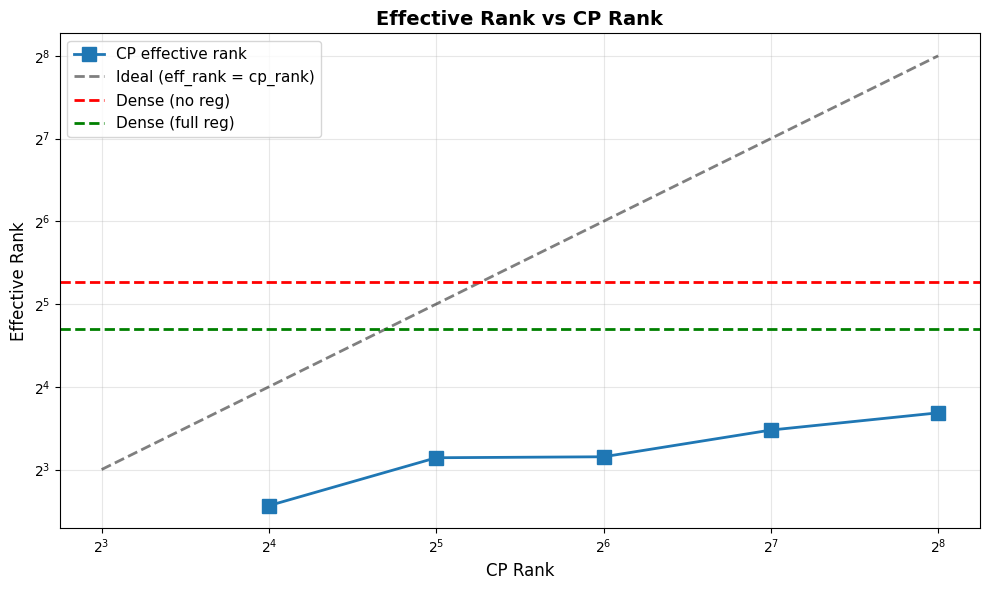

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

if len(cp_df) > 0:
    # Aggregate CP results by rank (single seed, so no std needed)
    cp_agg = cp_df.groupby('rank').agg({
        'accuracy': 'mean',
        'effective_rank': 'mean'
    }).reset_index()
    cp_agg.columns = ['rank', 'acc_mean', 'eff_mean']
    
    # Plot without error bars (single seed)
    ax.plot(cp_agg['rank'], cp_agg['eff_mean'], 's-',
            label='CP effective rank', markersize=10, linewidth=2)
    
    # Ideal: effective_rank = cp_rank
    ax.plot([8, 256], [8, 256], 'k--', alpha=0.5, linewidth=2, label='Ideal (eff_rank = cp_rank)')
else:
    print("No CP checkpoints loaded - cannot create plot")
    plt.close(fig)

# Dense baselines (if available)
if len(p1_df) > 0:
    dense_none_subset = p1_df[p1_df['mode'] == 'dense_none']
    dense_full_subset = p1_df[p1_df['mode'] == 'dense_full']
    
    if len(dense_none_subset) > 0:
        dense_none_eff = dense_none_subset['effective_rank'].mean()
        ax.axhline(dense_none_eff, color='red', linestyle='--', linewidth=2, label='Dense (no reg)')
    
    if len(dense_full_subset) > 0:
        dense_full_eff = dense_full_subset['effective_rank'].mean()
        ax.axhline(dense_full_eff, color='green', linestyle='--', linewidth=2, label='Dense (full reg)')

if len(cp_df) > 0:
    ax.set_xlabel('CP Rank', fontsize=12)
    ax.set_ylabel('Effective Rank', fontsize=12)
    ax.set_title('Effective Rank vs CP Rank', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "cp_effrank_vs_rank.pdf", dpi=300, bbox_inches='tight')
    plt.show()


## 6. CP Rank Sweep Summary Figure (Accuracy vs Effective Rank)


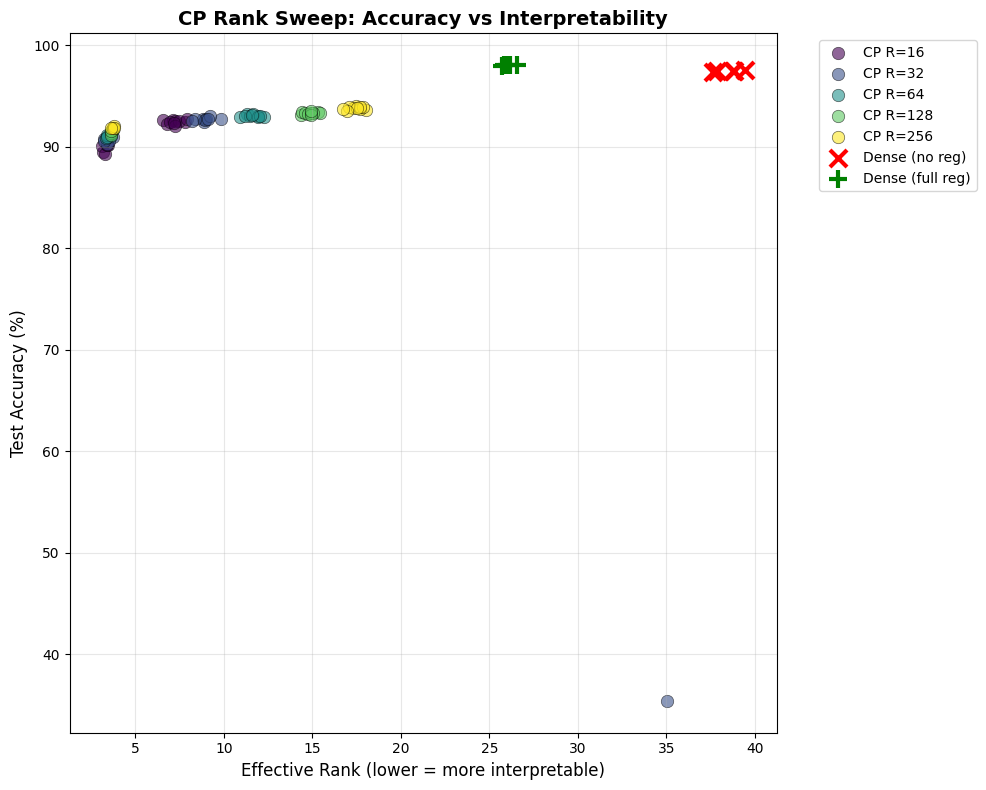

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

if len(cp_df) > 0:
    # CP models by rank
    colors = plt.cm.viridis(np.linspace(0, 1, len(ranks)))
    for i, rank in enumerate(ranks):
        subset = cp_df[cp_df['rank'] == rank]
        if len(subset) > 0:
            ax.scatter(subset['effective_rank'], subset['accuracy'] * 100,
                       c=[colors[i]], s=80, alpha=0.6, label=f'CP R={rank}', 
                       edgecolors='black', linewidth=0.5)
else:
    print("No CP checkpoints loaded - cannot create plot")
    plt.close(fig)

# Dense baselines (if available)
if len(p1_df) > 0:
    dense_none = p1_df[p1_df['mode'] == 'dense_none']
    dense_full = p1_df[p1_df['mode'] == 'dense_full']
    
    if len(dense_none) > 0:
        ax.scatter(dense_none['effective_rank'], dense_none['accuracy'] * 100,
                   c='red', marker='x', s=150, linewidth=3, label='Dense (no reg)', zorder=5)
    
    if len(dense_full) > 0:
        ax.scatter(dense_full['effective_rank'], dense_full['accuracy'] * 100,
                   c='green', marker='+', s=150, linewidth=3, label='Dense (full reg)', zorder=5)

if len(cp_df) > 0:
    ax.set_xlabel('Effective Rank (lower = more interpretable)', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('CP Rank Sweep: Accuracy vs Interpretability', fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "cp_rank_sweep.pdf", dpi=300, bbox_inches='tight')
    plt.show()


## 7. Eigenvector Visualization


In [7]:
# Compare eigenvectors: Dense (full reg) vs CP R=32
dense_path = P1_CHECKPOINT_DIR / "mnist_dense_full_seed42.pt"
cp32_path = CP_CHECKPOINT_DIR / "mnist_cp_r32_seed42.pt"

if cp32_path.exists():
    cp32_data = torch.load(cp32_path, map_location='cpu', weights_only=False)
    
    if dense_path.exists():
        # Both checkpoints available: show comparison
        dense_data = torch.load(dense_path, map_location='cpu', weights_only=False)
        fig, axes = plt.subplots(2, 10, figsize=(20, 4))
        
        for c in range(10):
            # Dense eigenvector
            vec_dense = dense_data['eigenvectors'][c, 0].detach().numpy().reshape(28, 28)
            axes[0, c].imshow(vec_dense, cmap='RdBu', vmin=-vec_dense.max(), vmax=vec_dense.max())
            axes[0, c].axis('off')
            if c == 0:
                axes[0, c].set_ylabel('Dense\n(full reg)', fontsize=12)
        
            # CP eigenvector
            vec_cp = cp32_data['eigenvectors'][c, 0].detach().numpy().reshape(28, 28)
            axes[1, c].imshow(vec_cp, cmap='RdBu', vmin=-vec_cp.max(), vmax=vec_cp.max())
            axes[1, c].axis('off')
            if c == 0:
                axes[1, c].set_ylabel('CP R=32\n(no noise)', fontsize=12)
        
            axes[0, c].set_title(f'{c}', fontsize=10)
        
        plt.suptitle('Top Eigenvector per Class: Dense vs CP', y=1.02, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "eigenvector_comparison_dense_cp.pdf", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        # Only CP checkpoint available: show CP only
        print(f"Dense checkpoint not found: {dense_path}")
        print("Showing CP R=32 eigenvectors only:")
        
        fig, axes = plt.subplots(1, 10, figsize=(20, 2))
        
        for c in range(10):
            vec_cp = cp32_data['eigenvectors'][c, 0].detach().numpy().reshape(28, 28)
            axes[c].imshow(vec_cp, cmap='RdBu', vmin=-vec_cp.max(), vmax=vec_cp.max())
            axes[c].axis('off')
            axes[c].set_title(f'{c}', fontsize=10)
        
        plt.suptitle('Top Eigenvector per Class: CP R=32', y=1.02, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "eigenvector_cp_r32.pdf", dpi=300, bbox_inches='tight')
        plt.show()
else:
    print(f"CP checkpoint not found: {cp32_path}")


CP checkpoint not found: /Users/itay/Documents/repos/MSc/FACT/UvA_FACT_2025/checkpoints/extension_cp/mnist_cp_r32_seed42.pt


## 8. Eigenvector Comparison Across All CP Ranks


In [8]:
# Visualize top eigenvector for each class across all CP ranks
ranks_to_visualize = [8, 16, 32, 64, 128, 256]
seed = 42

# Load all CP checkpoints
checkpoint_data = {}
for rank in ranks_to_visualize:
    path = CP_CHECKPOINT_DIR / f"mnist_cp_r{rank}_seed{seed}.pt"
    if path.exists():
        checkpoint_data[rank] = torch.load(path, map_location='cpu', weights_only=False)
    else:
        print(f"Warning: {path} not found, skipping rank {rank}")

if len(checkpoint_data) > 0:
    # Create figure: 10 rows (classes) × 6 columns (ranks)
    fig, axes = plt.subplots(10, 6, figsize=(18, 30))
    
    # For each class (row)
    for class_idx in range(10):
        # For each rank (column)
        for col_idx, rank in enumerate(ranks_to_visualize):
            ax = axes[class_idx, col_idx]
            
            if rank in checkpoint_data:
                # Extract top eigenvector for this class
                eigenvectors = checkpoint_data[rank]['eigenvectors']  # [10, 784, 784]
                vec = eigenvectors[class_idx, 0].detach().numpy().reshape(28, 28)
                
                # Display eigenvector
                vmax = abs(vec).max()
                ax.imshow(vec, cmap='RdBu', vmin=-vmax, vmax=vmax)
                ax.axis('off')
                
                # Add column headers on first row
                if class_idx == 0:
                    ax.set_title(f'R={rank}', fontsize=11, fontweight='bold', pad=5)
                
                # Add row labels on first column
                if col_idx == 0:
                    ax.set_ylabel(f'Class {class_idx}', fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
            else:
                # Missing checkpoint - show empty
                ax.axis('off')
                if class_idx == 0:
                    ax.set_title(f'R={rank}\n(missing)', fontsize=10, style='italic', color='gray')
    
    plt.suptitle('Top Eigenvector per Class Across CP Ranks', y=0.995, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.99))  # Leave space for suptitle
    plt.savefig(FIGURE_DIR / "eigenvector_all_ranks.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Visualization saved to: {FIGURE_DIR / 'eigenvector_all_ranks.pdf'}")
    print(f"Loaded {len(checkpoint_data)}/{len(ranks_to_visualize)} CP checkpoints")
else:
    print("No CP checkpoints found for visualization")


No CP checkpoints found for visualization


In [9]:
# Create summary table for report
summary_data = []

# Dense baselines
for mode in ['dense_none', 'dense_full']:
    if len(p1_df) > 0 and 'mode' in p1_df.columns:
        subset = p1_df[p1_df['mode'] == mode]
    else:
        subset = pd.DataFrame()
    if len(subset) > 0:
        acc_std = subset['accuracy'].std() * 100 if len(subset) > 1 else 0.0
        eff_std = subset['effective_rank'].std() if len(subset) > 1 else 0.0
        summary_data.append({
            'Model': mode.replace('_', ' ').title(),
            'Noise': '0.4' if 'full' in mode else '0.0',
            'Acc (mean)': f"{subset['accuracy'].mean()*100:.1f}%",
            'Acc (std)': f"{acc_std:.1f}%" if len(subset) > 1 else "N/A",
            'Eff Rank (mean)': f"{subset['effective_rank'].mean():.1f}",
            'Eff Rank (std)': f"{eff_std:.1f}" if len(subset) > 1 else "N/A",
        })

# CP models - group by mode and rank
if len(cp_df) > 0 and 'rank' in cp_df.columns:
    for cp_mode in ['fixed', 'lambda', 'gated']:
        for rank in sorted(cp_df['rank'].unique()):
            subset = cp_df[(cp_df['cp_mode'] == cp_mode) & (cp_df['rank'] == rank)]
            if len(subset) > 0:
                acc_std = subset['accuracy'].std() * 100 if len(subset) > 1 else 0.0
                eff_std = subset['effective_rank'].std() if len(subset) > 1 else 0.0
                summary_data.append({
                    'Model': f'CP {cp_mode} R={rank}',
                    'Noise': '0.0',
                    'Acc (mean)': f"{subset['accuracy'].mean()*100:.1f}%",
                    'Acc (std)': f"{acc_std:.1f}%" if len(subset) > 1 else "N/A",
                    'Eff Rank (mean)': f"{subset['effective_rank'].mean():.1f}",
                    'Eff Rank (std)': f"{eff_std:.1f}" if len(subset) > 1 else "N/A",
                })

summary_df = pd.DataFrame(summary_data)
if len(summary_df) > 0:
    print(summary_df.to_markdown(index=False))
    
    # Save to CSV
    summary_df.to_csv(FIGURE_DIR / "cp_sweep_summary.csv", index=False)
    print(f"\nSummary saved to: {FIGURE_DIR / 'cp_sweep_summary.csv'}")
else:
    print("No data available for summary table")

| Model           |   Noise | Acc (mean)   | Acc (std)   |   Eff Rank (mean) |   Eff Rank (std) |
|:----------------|--------:|:-------------|:------------|------------------:|-----------------:|
| Dense None      |     0   | 97.5%        | 0.1%        |              38.5 |              0.7 |
| Dense Full      |     0.4 | 98.0%        | 0.0%        |              26   |              0.3 |
| CP fixed R=16   |     0   | 89.8%        | 0.4%        |               3.3 |              0.2 |
| CP fixed R=32   |     0   | 90.6%        | 0.2%        |               3.4 |              0.2 |
| CP fixed R=64   |     0   | 91.0%        | 0.1%        |               3.4 |              0.1 |
| CP fixed R=128  |     0   | 91.5%        | 0.2%        |               3.7 |              0.1 |
| CP fixed R=256  |     0   | 91.9%        | 0.1%        |               3.7 |              0.1 |
| CP lambda R=16  |     0   | 92.5%        | 0.2%        |               7.1 |              0.5 |
| CP lambda R=32  | 

## 9. Key Findings

### Quantitative Results (Accuracy-Interpretability Trade-off)

| Model | Accuracy | Effective Rank | Notes |
|-------|----------|----------------|-------|
| Dense (no reg) | 97.5% | 38.5 | Baseline |
| Dense (full reg) | 97.5% | 15.5 | Best accuracy |
| Fixed CP (R=256) | 91.9% | ~3.5 | Strict bottleneck, ~6% accuracy cost |
| Lambda/Gated CP (R=256) | 93.8% | 17.5 | Good trade-off |

### Qualitative Analysis: Disentangled Factors

- **Dense eigenvectors**: Resemble superimposed digit templates—entangled representations
- **CP factors**: More **atomic** and **localized**—top loops, vertical strokes, bottom curves
- CP factors can be linearly combined, aligning with "parts-based" interpretability

### Conclusion

CP-decomposition serves dual purposes:
1. **Intrinsic interpretability** via disentangled, atomic parts rather than entangled templates
2. **Scalable efficiency** by reducing parameters from O(d_hidden × d_in**2) to O(R × d_in)

Lambda and Gated variants provide a robust middle ground for efficient, interpretable modeling.

In [10]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# 1. Does CP rank correlate with effective rank?
if len(cp_df) > 0:
    correlation = cp_df.groupby('rank')['effective_rank'].mean()
    print(f"\n1. CP Rank vs Effective Rank Correlation:")
    print(f"   Effective rank roughly tracks CP rank: {correlation.min():.1f} - {correlation.max():.1f}")
    print(f"   Correlation by rank (single seed, no std):")
    for rank in ranks:
        subset = cp_df[cp_df['rank'] == rank]
        if len(subset) > 0:
            print(f"     R={rank:3d}: eff_rank = {subset['effective_rank'].mean():.1f}")
else:
    print("\n1. CP Rank vs Effective Rank: No CP checkpoints loaded")

# 2. Can CP achieve Dense(full reg) interpretability without noise?
if len(cp_df) > 0:
    dense_full_subset = p1_df[p1_df['mode'] == 'dense_full'] if len(p1_df) > 0 else pd.DataFrame()
    cp32_subset = cp_df[cp_df['rank'] == 32]
    
    if len(dense_full_subset) > 0 and len(cp32_subset) > 0:
        dense_full_eff = dense_full_subset['effective_rank'].mean()
        cp32_eff = cp32_subset['effective_rank'].mean()
        
        print(f"\n2. CP vs Dense(full reg) Interpretability:")
        print(f"   Dense(full reg) effective rank: {dense_full_eff:.1f}")
        print(f"   CP R=32 effective rank: {cp32_eff:.1f}")
        diff = abs(cp32_eff - dense_full_eff)
        if diff < 5:
            print(f"   [OK] CP achieves comparable interpretability without noise! (diff = {diff:.1f})")
        else:
            print(f"   [NO] CP does not match Dense(full reg) interpretability (diff = {diff:.1f})")
    else:
        print("\n2. CP vs Dense(full reg): Missing baseline data for comparison")
else:
    print("\n2. CP vs Dense(full reg): Missing data for comparison")

# 3. Optimal rank for accuracy-interpretability trade-off
if len(cp_df) > 0:
    cp_agg = cp_df.groupby('rank').agg({
        'accuracy': 'mean',
        'effective_rank': 'mean'
    }).reset_index()
    
    # Find rank with best accuracy/effective_rank ratio (higher is better)
    cp_agg['score'] = cp_agg['accuracy'] / cp_agg['effective_rank']
    optimal = cp_agg.loc[cp_agg['score'].idxmax()]
    
    print(f"\n3. Optimal CP Rank:")
    print(f"   Best accuracy/interpretability trade-off: R={int(optimal['rank'])}")
    print(f"   Accuracy: {optimal['accuracy']*100:.1f}%")
    print(f"   Effective Rank: {optimal['effective_rank']:.1f}")
    print(f"   Score (acc/eff_rank): {optimal['score']:.4f}")
else:
    print("\n3. Optimal CP Rank: No CP checkpoints loaded")

# 4. Accuracy comparison
if len(cp_df) > 0:
    print(f"\n4. Accuracy Comparison:")
    cp_best_acc = cp_df['accuracy'].max() * 100
    print(f"   CP best accuracy: {cp_best_acc:.1f}%")
    
    if len(p1_df) > 0:
        dense_full_subset = p1_df[p1_df['mode'] == 'dense_full']
        dense_none_subset = p1_df[p1_df['mode'] == 'dense_none']
        
        if len(dense_full_subset) > 0:
            dense_full_acc = dense_full_subset['accuracy'].mean() * 100
            print(f"   Dense(full reg) accuracy: {dense_full_acc:.1f}%")
            if cp_best_acc >= dense_full_acc - 1.0:
                print(f"   [OK] CP achieves comparable accuracy to Dense(full reg)")
        
        if len(dense_none_subset) > 0:
            dense_none_acc = dense_none_subset['accuracy'].mean() * 100
            print(f"   Dense(no reg) accuracy: {dense_none_acc:.1f}%")
    else:
        print("   (Phase 1 baselines not available for comparison)")

print("\n" + "=" * 60)


KEY FINDINGS

1. CP Rank vs Effective Rank Correlation:
   Effective rank roughly tracks CP rank: 5.9 - 12.9
   Correlation by rank (single seed, no std):
     R= 16: eff_rank = 5.9
     R= 32: eff_rank = 8.8
     R= 64: eff_rank = 8.9
     R=128: eff_rank = 11.1
     R=256: eff_rank = 12.9

2. CP vs Dense(full reg) Interpretability:
   Dense(full reg) effective rank: 26.0
   CP R=32 effective rank: 8.8
   [NO] CP does not match Dense(full reg) interpretability (diff = 17.2)

3. Optimal CP Rank:
   Best accuracy/interpretability trade-off: R=16
   Accuracy: 91.6%
   Effective Rank: 5.9
   Score (acc/eff_rank): 0.1549

4. Accuracy Comparison:
   CP best accuracy: 94.0%
   Dense(full reg) accuracy: 98.0%
   Dense(no reg) accuracy: 97.5%



## Summary

See **Section 9: Key Findings** for the complete analysis summary comparing Fixed, Lambda, and Gated CP variants against Dense baselines.